Ques 1 :-  What is Boosting in Machine Learning? Explain how it improves weak
learners.

Boosting in machine learning is an ensemble technique that combines multiple weak learners to form a strong predictive model. A weak learner is a simple model, such as a shallow decision tree, that performs only slightly better than random guessing. Boosting works by training these learners sequentially, where each new learner focuses on the mistakes made by the previous ones. Misclassified or difficult data points are given more weight so that subsequent learners pay extra attention to them. Finally, the predictions of all learners are combined, often through weighted voting or averaging, to produce a highly accurate model. This process improves weak learners by systematically reducing bias and error, ensuring that the final model is robust and performs well even on complex datasets. Popular boosting algorithms include AdaBoost, Gradient Boosting, XGBoost, LightGBM, and CatBoost, each offering variations in efficiency and accuracy.

Ques 2:- What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?

Answer:- The key difference between AdaBoost and Gradient Boosting lies in how they train models and handle errors.

AdaBoost works by adjusting the weights of training samples: after each weak learner is trained, it increases the weights of misclassified samples so that the next learner focuses more on those difficult cases. In this way, each subsequent model pays extra attention to the mistakes of the previous one, and the final prediction is made by combining all learners with weighted voting.

Gradient Boosting, on the other hand, takes a more mathematical approach. Instead of reweighting samples, it fits each new learner to the residual errors (the difference between the actual values and the predictions) of the previous model. This is done using gradient descent to minimize a chosen loss function. Each learner is trained to correct the errors of the ensemble so far, and the models are combined additively to improve accuracy step by step.

In short, AdaBoost emphasizes misclassified samples by reweighting them, while Gradient Boosting reduces errors by fitting learners to residuals using gradient descent. Both aim to convert weak learners into a strong model, but they differ in how they guide the training process.

Ques 3 :-How does regularization help in XGBoost?

Answer:-Regularization in XGBoost helps prevent overfitting and improves the generalization ability of the model by penalizing overly complex trees. Unlike traditional boosting methods, XGBoost introduces both L1 (Lasso) and L2 (Ridge) regularization terms directly into its objective function. These penalties discourage the model from creating trees with too many branches or assigning excessively large weights to features, which could otherwise lead to memorizing the training data instead of learning meaningful patterns. By controlling model complexity, regularization ensures that the boosted ensemble remains robust, stable, and performs well on unseen data. In practice, this makes XGBoost more reliable than standard gradient boosting, especially when working with noisy or high-dimensional datasets.

Ques 4 :- Why is CatBoost considered efficient for handling categorical data?

Answer:-CatBoost is considered highly efficient for handling categorical data because it uses a unique technique called ordered target statistics and permutation-driven encoding. Instead of relying on traditional one-hot encoding, which can explode feature dimensions and slow down training, CatBoost transforms categorical features into numerical values based on the distribution of target labels. It does this in a way that avoids target leakage by applying permutations of the dataset and calculating statistics only from previous rows. This ordered approach ensures that the model learns meaningful patterns from categorical variables without overfitting. Additionally, CatBoost automatically handles categorical features during training, reducing the need for extensive preprocessing and making it particularly effective for datasets with many categorical variables. This efficiency, combined with its robustness and speed, is why CatBoost is often preferred in real-world applications where categorical data is dominant.

Ques 5:-What are some real-world applications where boosting techniques are
preferred over bagging methods?

Answer:-Boosting techniques are often preferred over bagging methods in real-world applications where high accuracy and bias reduction are crucial. For example, in fraud detection within banking and e-commerce, boosting models like XGBoost are widely used because they can focus on rare, hard-to-classify fraudulent transactions, minimizing costly false negatives. In healthcare, boosting methods such as Gradient Boosting and CatBoost are applied to medical diagnosis tasks like cancer detection or predicting diabetes risk, where capturing subtle patterns in patient data is essential. Recommendation systems in retail and streaming platforms also rely on boosting to refine personalization by learning complex user behavior patterns. Similarly, in financial risk modeling, boosting helps in credit scoring and loan approval by accurately identifying high-risk applicants. Even in natural language processing tasks such as sentiment analysis, spam detection, and text classification, boosting is favored because it handles imbalanced datasets effectively. In short, boosting is chosen in domains where precision and bias reduction matter more than stability, while bagging is better suited for tasks that require variance reduction and robustness.

In [1]:
# Ques 6:- Write a Python program to:
#● Train an AdaBoost Classifier on the Breast Cancer dataset
#● Print the model accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train AdaBoost Classifier
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.9649122807017544


In [2]:
#Ques 7:- Write a Python program to:
#● Train a Gradient Boosting Regressor on the California Housing dataset
#● Evaluate performance using R-squared score

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load the California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance using R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared Score:", r2)


R-squared Score: 0.7756446042829697


In [3]:
# Ques 8:- Write a Python program to:
#● Train an XGBoost Classifier on the Breast Cancer dataset
#● Tune the learning rate using GridSearchCV
#● Print the best parameters and accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load the Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define parameter grid for learning rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Get best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Evaluate accuracy on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)


Best Parameters: {'learning_rate': 0.2}
Test Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:10:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [5]:
pip install catBoost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


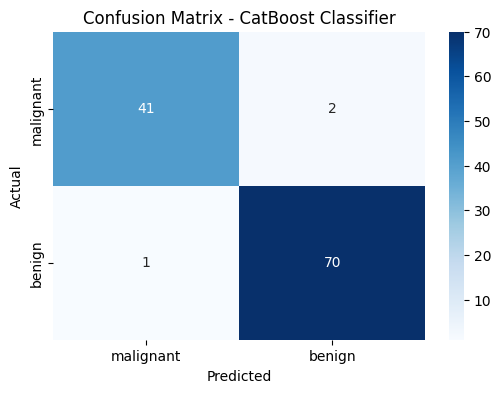

In [6]:
# Ques 9 :- Write a Python program to:
#● Train a CatBoost Classifier
#● Plot the confusion matrix using seaborn

from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train CatBoost Classifier
model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CatBoost Classifier')
plt.show()


Ques 10 :-  You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model

Answer:- In a FinTech setting where the goal is to predict loan default using customer demographics and transaction behavior, the data science pipeline would begin with careful preprocessing. Missing values in numeric features can be imputed with medians or model-based methods, while categorical features can be imputed with the mode or treated as a separate “missing” category. Since the dataset contains both numeric and categorical features, CatBoost is particularly efficient because it natively handles categorical variables and missing values, reducing preprocessing complexity. If XGBoost were chosen, one-hot or target encoding would be required, while AdaBoost would be less suitable given the mixed data types. After preprocessing, class imbalance must be addressed through techniques like SMOTE, undersampling, or by applying class weights within the boosting algorithm. Hyperparameter tuning would follow a two-stage strategy: randomized search to explore broad ranges of parameters such as learning rate, number of estimators, and tree depth, and then grid search to refine around the best candidates. For evaluation, accuracy alone would be misleading due to imbalance, so metrics like ROC-AUC, Precision-Recall AUC, and especially recall and F1-score would be prioritized, since missing a defaulter is far more costly than incorrectly flagging a safe borrower. From a business perspective, such a boosting-based model would reduce financial risk by accurately identifying high-risk customers, improve operational efficiency by automating loan approval decisions, enhance customer trust through responsible lending, and ultimately increase profitability by balancing risk segmentation with competitive interest rates.